In [68]:
from scipy.stats import poisson, binom, expon, norm
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import math
import numpy as np

In [ ]:
N = 5000
Realizzazioni = [10, 100, 1000, 10000, 100000]
x_min, x_max = [-2, 2]

Le seguenti celle sono costruite attorno a _r_ realizzazioni della variabile aleatoria _Y_, definita come la media campionaria di _N_ V.A. uniformi iid:\
Xi iid U(x_min, x_max).

Nel limite $r \to \infty$
Media prevista: 0.00000
Deviazione Standard prevista: 0.01633, 
Skewness prevista: 0.00000
Kurtosis prevista: -0.00000


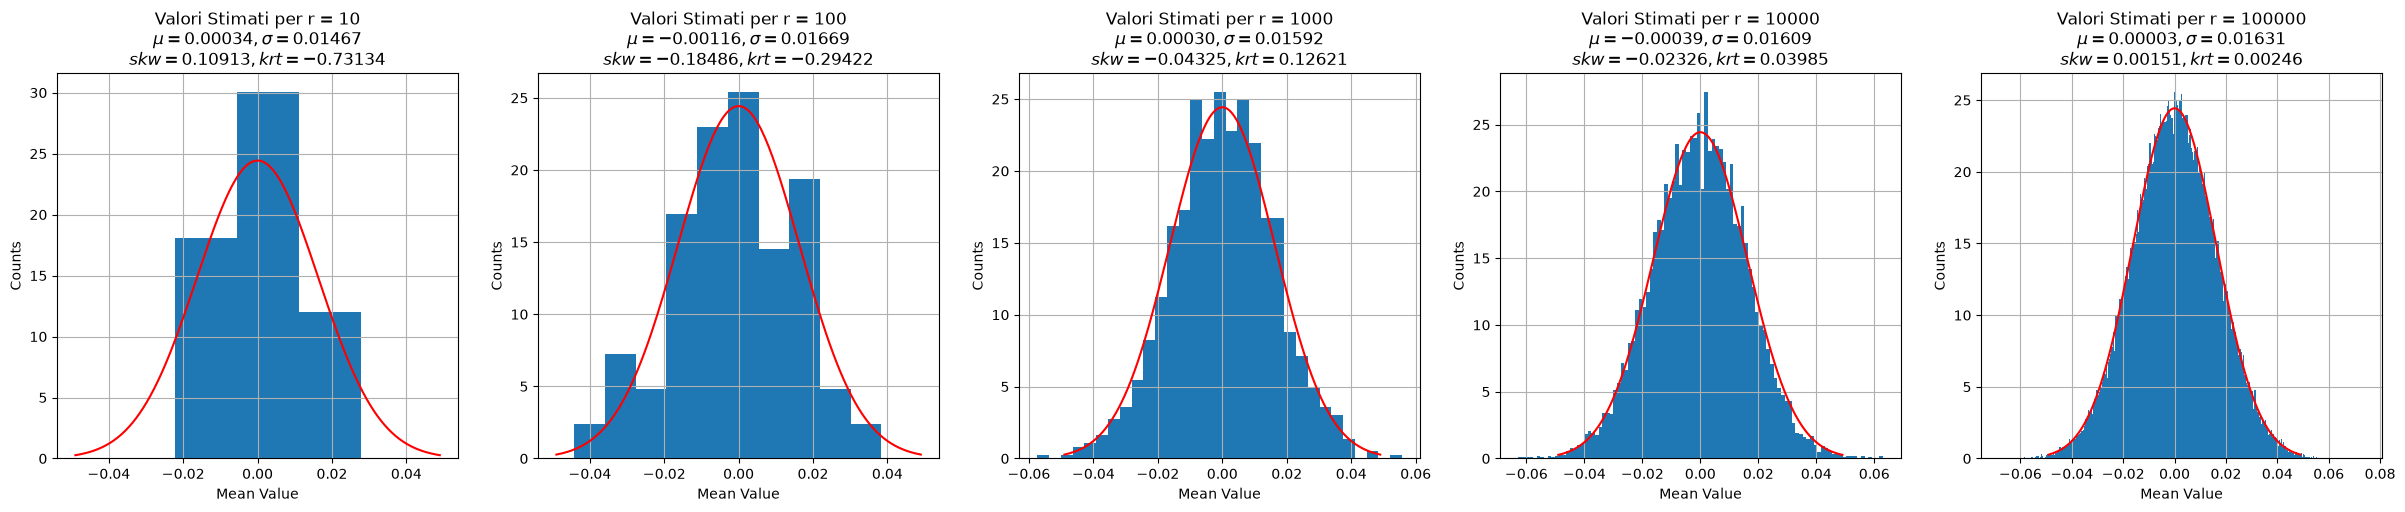

In [75]:
fig, ax = plt.subplots(1, len(Realizzazioni), figsize=(30, 5), sharex = False, sharey = False)

mu_prevista  = (x_max + x_min)/2
var_prevista = (x_max - x_min)**2/(12*N)
std_prevista = np.sqrt(var_prevista)
skw_prevista = 0
krt_prevista = -6/5 * N**(-3)

x_fit = np.linspace(mu_prevista - 3*std_prevista, mu_prevista + 3*std_prevista,200)
ref = norm.pdf(x_fit, loc=mu_prevista, scale=std_prevista)

print(fr"Nel limite $r \to \infty$")
print(f"Media prevista: {mu_prevista:.5f}\nDeviazione Standard prevista: {std_prevista:.5f}, \nSkewness prevista: {skw_prevista:.5f}\nKurtosis prevista: {krt_prevista:.5f}")

j = 0
for r in Realizzazioni:
    means = []
    for n in range(r):
        x = np.random.rand(1,N)
        x = x * (x_max - x_min) + x_min
        means.append(np.mean(x))

    means     = np.asarray(means)
    m_means   = np.mean(means)
    var_means = np.var(means)
    skw_means = skew(means)
    krt_means = kurtosis(means)
    
    ax[j].hist(means, bins=int(np.sqrt(r)), density=True)
    ax[j].set_xlabel("Mean Value")
    ax[j].set_ylabel("Counts")
    ax[j].set_title(f"Valori Stimati per r = {r}" + "\n" + fr"$\mu = {m_means:.5f}, \sigma = {np.sqrt(var_means):.5f}$" + "\n" + fr"$skw = {skw_means:.5f}, krt = {krt_means:.5f}$")
    ax[j].grid(True)
    ax[j].plot(x_fit, ref, color="red")
    
    j += 1

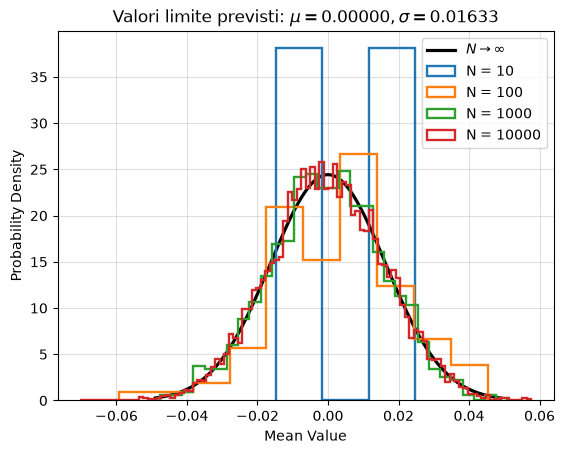

In [57]:
fig, ax = plt.subplots()

mu_prevista  = (x_max + x_min)/2
var_prevista = (x_max - x_min)**2/(12*N)
std_prevista = np.sqrt(var_prevista)
x_fit = np.linspace(mu_prevista - 3*std_prevista, mu_prevista + 3*std_prevista,200)
ref = norm.pdf(x_fit, loc=mu_prevista, scale=std_prevista)
ax.plot(x_fit, ref, color="black", linewidth=2.3, label=r"$N \to \infty$")


for r in Realizzazioni[:-1]:
    means = []
    for n in range(r):
        x = np.random.rand(1,N)
        x = x * (x_max - x_min) + x_min
        means.append(np.mean(x))

    means     = np.asarray(means)
    m_means   = np.mean(means)
    var_means = np.var(means)
    ax.hist(means, bins=int(np.sqrt(r)), density=True, histtype="step", linewidth=1.7, label=f"N = {r}")
    ax.set_xlabel("Mean Value")
    ax.set_ylabel("Probability Density")
    ax.set_title(fr"Valori limite previsti: $\mu = {mu_prevista:.5f}, \sigma = {std_prevista:.5f}$")
    ax.grid(True, alpha=0.4)
    ax.legend()

Le seguenti celle sono costruite attorno a _r_ realizzazioni della variabile aleatoria _Y_, definita come la media campionaria di _N_ V.A. binomiali iid:\
Xi iid Binom(M,p).

Nel limite $r \to \infty$
Media prevista: 7.00000
Deviazione Standard prevista: 0.03017, 
Skewness prevista: 0.00000
Kurtosis prevista: -0.00000


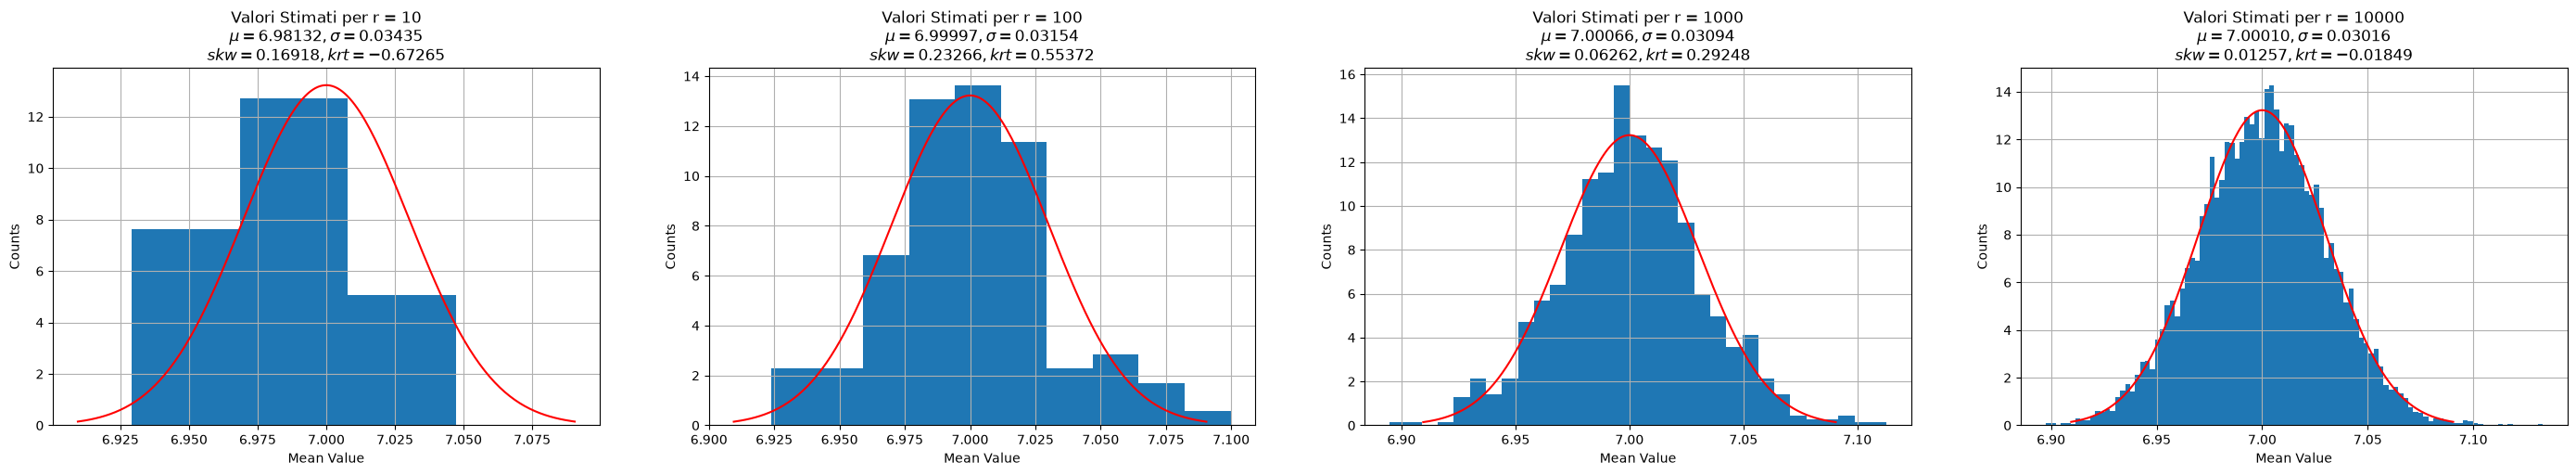

In [76]:
fig, ax = plt.subplots(1, len(Realizzazioni), figsize=(35, 5), sharex = False, sharey = False)

n = 20
p = 0.35
q = 1-p

mu_prevista  = n*p
var_prevista = n*p*q * N**(-1)
std_prevista = np.sqrt(var_prevista)
skw_prevista = (q-p)/np.sqrt(n*p*q) * N**(-2)
krt_prevista = (1-6*p*q)/(n*p*q) * N**(-3)

x_fit = np.linspace(mu_prevista - 3*std_prevista, mu_prevista + 3*std_prevista,200)
ref = norm.pdf(x_fit, loc=mu_prevista, scale=std_prevista)
print(fr"Nel limite $r \to \infty$")
print(f"Media prevista: {mu_prevista:.5f}\nDeviazione Standard prevista: {std_prevista:.5f}, \nSkewness prevista: {skw_prevista:.5f}\nKurtosis prevista: {krt_prevista:.5f}")

j = 0
for r in Realizzazioni:
    means = []
    for i in range(r):
        x = binom.rvs(n, p, size=N)
        # x = x * (x_max - x_min) + x_min
        means.append(np.mean(x))

    means     = np.asarray(means)
    m_means   = np.mean(means)
    var_means = np.var(means)
    skw_means = skew(means)
    krt_means = kurtosis(means)
    
    ax[j].hist(means, bins=int(np.sqrt(r)), density=True)
    ax[j].set_xlabel("Mean Value")
    ax[j].set_ylabel("Counts")
    ax[j].set_title(f"Valori Stimati per r = {r}" + "\n" + fr"$\mu = {m_means:.5f}, \sigma = {np.sqrt(var_means):.5f}$" + "\n" + fr"$skw = {skw_means:.5f}, krt = {krt_means:.5f}$")
    ax[j].grid(True)
    ax[j].plot(x_fit, ref, color="red")
    
    j += 1

Le seguenti celle sono costruite attorno a _r_ realizzazioni della variabile aleatoria _Y_, definita come la media campionaria di _N_ V.A. esponenziali iid:\
Xi iid Exp(lambda).

Nel limite $r \to \infty$
Media prevista: 0.05000
Deviazione Standard prevista: 0.00071
Skewness prevista: 0.00000
Kurtosis prevista: 0.00000


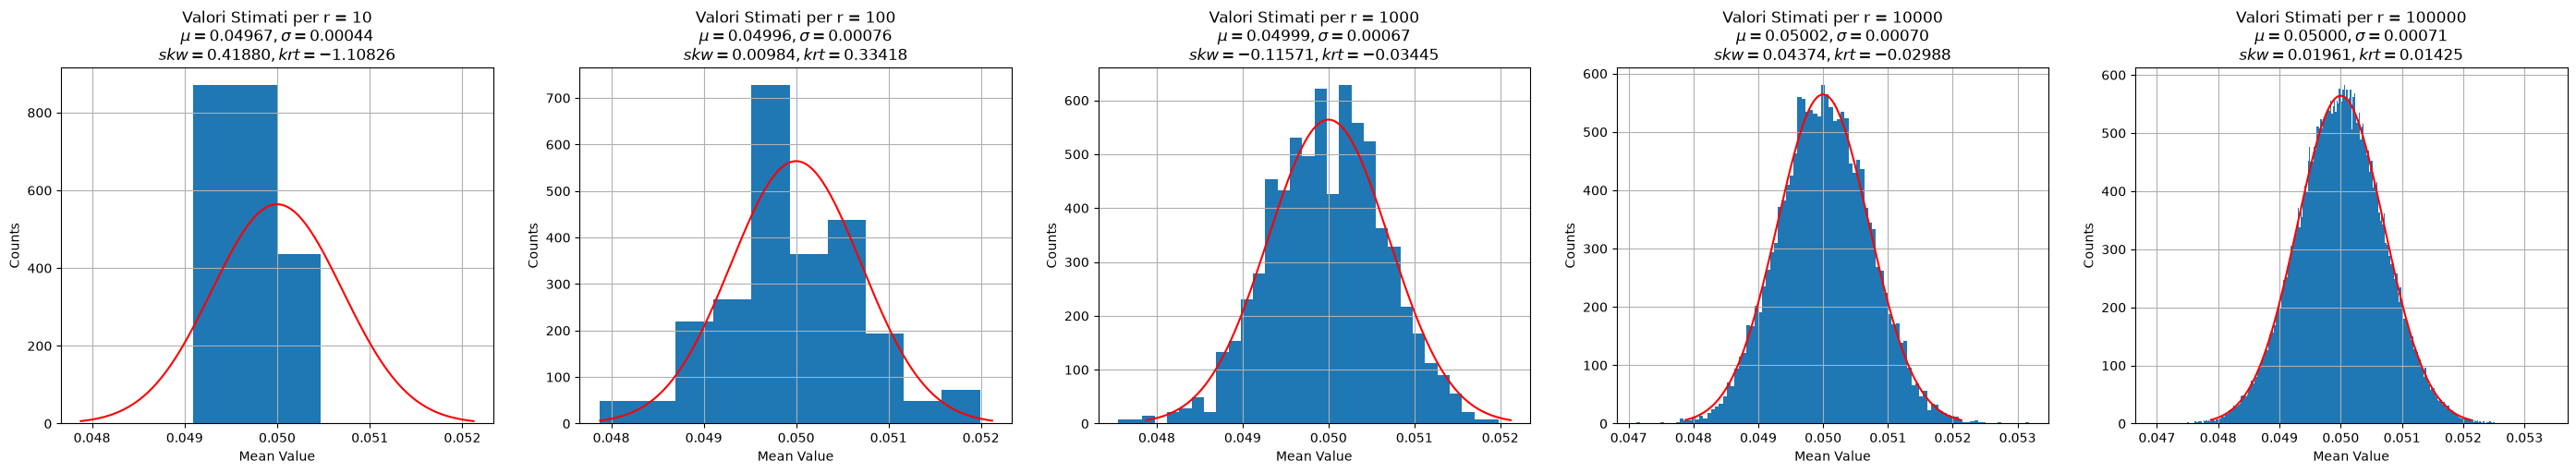

In [78]:
fig, ax = plt.subplots(1, len(Realizzazioni), figsize=(35, 5), sharex = False, sharey = False)

l = 20 # lambda > 0

mu_prevista  = l ** (-1)
var_prevista = l ** (-2) * N**(-1)
std_prevista = np.sqrt(var_prevista)
skw_prevista = 2 * N**(-2)
krt_prevista = 6 * N**(-3)

x_fit = np.linspace(mu_prevista - 3*std_prevista, mu_prevista + 3*std_prevista,200)
ref = norm.pdf(x_fit, loc=mu_prevista, scale=std_prevista)
print(fr"Nel limite $r \to \infty$")
print(f"Media prevista: {mu_prevista:.5f}\nDeviazione Standard prevista: {std_prevista:.5f}\nSkewness prevista: {skw_prevista:.5f}\nKurtosis prevista: {krt_prevista:.5f}")

j = 0
for r in Realizzazioni:
    means = []
    for i in range(r):
        x = expon.rvs(scale=1/l, size=N)
        # x = x * (x_max - x_min) + x_min
        means.append(np.mean(x))

    means     = np.asarray(means)
    m_means   = np.mean(means)
    var_means = np.var(means)
    skw_means = skew(means)
    krt_means = kurtosis(means)
    
    ax[j].hist(means, bins=int(np.sqrt(r)), density=True)
    ax[j].set_xlabel("Mean Value")
    ax[j].set_ylabel("Counts")
    ax[j].set_title(f"Valori Stimati per r = {r}" + "\n" + fr"$\mu = {m_means:.5f}, \sigma = {np.sqrt(var_means):.5f}$" + "\n" + fr"$skw = {skw_means:.5f}, krt = {krt_means:.5f}$")
    ax[j].grid(True)
    ax[j].plot(x_fit, ref, color="red")
    
    j += 1

Le seguenti celle sono costruite attorno a _r_ realizzazioni della variabile aleatoria _Y_, definita come la media campionaria di _N_ V.A. poissoniane iid:\
Xi iid Pois(lambda).

Nel limite $r \to \infty$
Media prevista: 20.00000
Deviazione Standard prevista: 0.06325
Skewness prevista: 0.00000
Kurtosis prevista: 0.00000


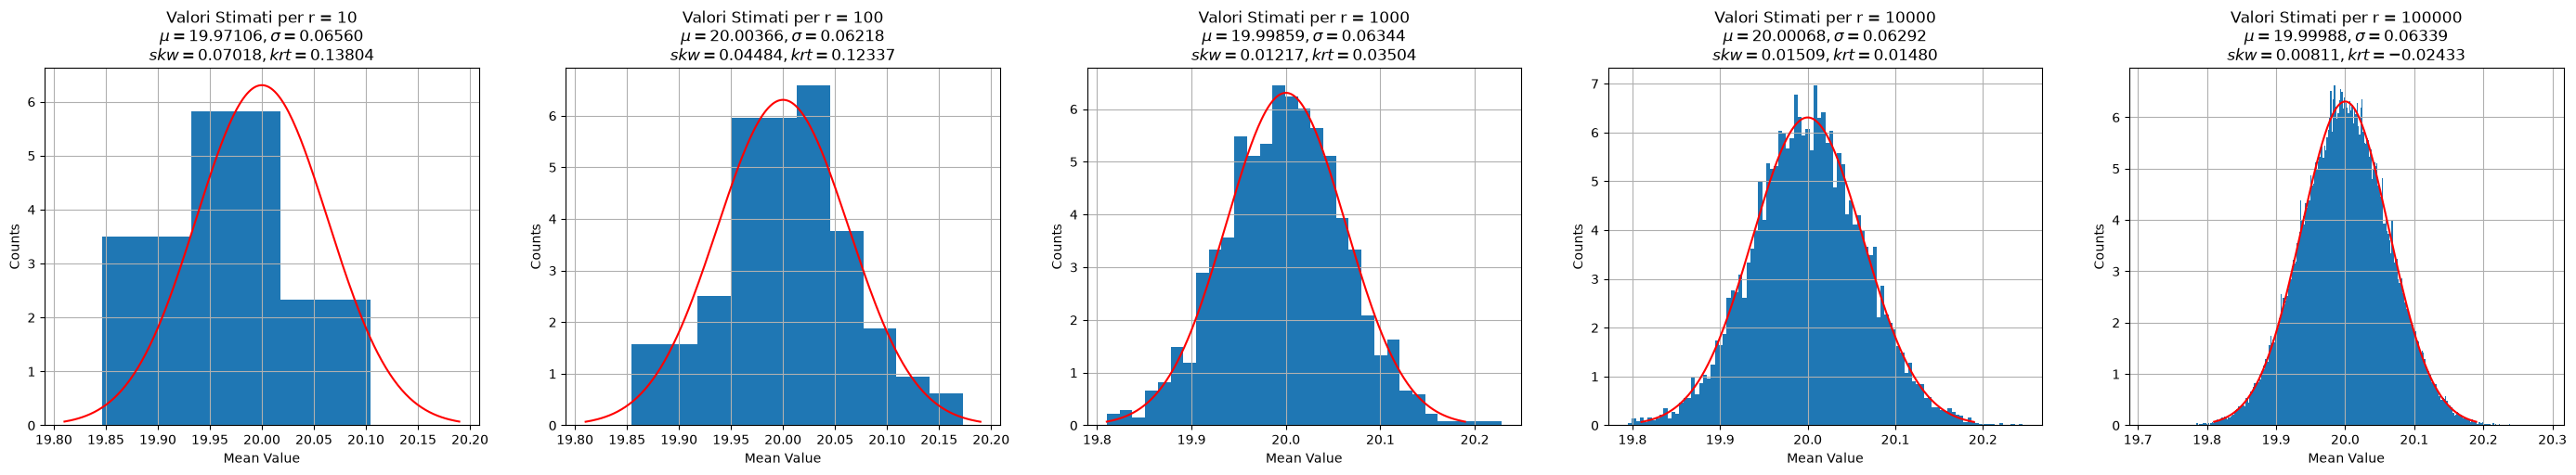

In [82]:
fig, ax = plt.subplots(1, len(Realizzazioni), figsize=(35, 5), sharex = False, sharey = False)

l = 20 # lambda > 0

mu_prevista  = l
var_prevista = l * N**(-1)
std_prevista = np.sqrt(var_prevista)
skw_prevista = l**(-1/2) * N**(-2)
krt_prevista = l**(-1) * N**(-3)

x_fit = np.linspace(mu_prevista - 3*std_prevista, mu_prevista + 3*std_prevista,200)
ref = norm.pdf(x_fit, loc=mu_prevista, scale=std_prevista)
print(fr"Nel limite $r \to \infty$")
print(f"Media prevista: {mu_prevista:.5f}\nDeviazione Standard prevista: {std_prevista:.5f}\nSkewness prevista: {skw_prevista:.5f}\nKurtosis prevista: {krt_prevista:.5f}")

j = 0
for r in Realizzazioni:
    means = []
    for i in range(r):
        x = poisson.rvs(l, size=N)
        # x = x * (x_max - x_min) + x_min
        means.append(np.mean(x))

    means     = np.asarray(means)
    m_means   = np.mean(means)
    var_means = np.var(means)
    skw_means = skew(means)
    krt_means = kurtosis(means)
    
    ax[j].hist(means, bins=int(np.sqrt(r)), density=True)
    ax[j].set_xlabel("Mean Value")
    ax[j].set_ylabel("Counts")
    ax[j].set_title(f"Valori Stimati per r = {r}" + "\n" + fr"$\mu = {m_means:.5f}, \sigma = {np.sqrt(var_means):.5f}$" + "\n" + fr"$skw = {skw_means:.5f}, krt = {krt_means:.5f}$")
    ax[j].grid(True)
    ax[j].plot(x_fit, ref, color="red")
    
    j += 1